# ============================================================
# THESIS: Modeling and Forecasting Stock Prices in the
# NASDAQ-100 Index Using ARIMA and SARIMA
# Stock: APPLE (AAPL)
# Author: William Sanjaya Kesuma
# ============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import requests
import warnings
warnings.filterwarnings('ignore')
 
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import pmdarima as pm

In [2]:
print("=" * 60)
print("STEP 1: LOADING DATA")
print("=" * 60)

url = "https://raw.githubusercontent.com/WilliamKesuma/Stock-Data-Analysis/refs/heads/main/datasets/AAPL-Price%20History_20260331_0843.csv"
response = requests.get(url)

# Find the row where actual daily data begins
lines = response.text.splitlines()
header_row = None
for i, line in enumerate(lines):
    if line.startswith("Exchange Date"):
        header_row = i
        break

df = pd.read_csv(
    io.StringIO(response.text),
    skiprows=header_row,
    sep=';',
    decimal=',',
    thousands='.'
)

df = df.dropna(subset=['Exchange Date'])
df['Date'] = pd.to_datetime(df['Exchange Date'], format='%d-%b-%Y')
df.set_index('Date', inplace=True)
df = df.sort_index()
df = df[['Close', 'Open', 'Low', 'High', 'Volume']].dropna(subset=['Close'])
 
print(f"Data loaded successfully!")
print(f"Date range : {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total rows : {len(df)}")

STEP 1: LOADING DATA
Data loaded successfully!
Date range : 2022-01-03 to 2025-12-31
Total rows : 1003


In [ ]:
print("\n" + "=" * 60)
print("STEP 2: TRAIN / TEST SPLIT (80% / 20%)")
print("=" * 60)
 
train_size = int(len(df) * 0.8)
train_data = df['Close'].iloc[:train_size]
test_data  = df['Close'].iloc[train_size:]
 
print(f"Training set : {train_data.index[0].date()} to {train_data.index[-1].date()} ({len(train_data)} rows)")
print(f"Testing set  : {test_data.index[0].date()} to {test_data.index[-1].date()} ({len(test_data)} rows)")


STEP 2: TRAIN / TEST SPLIT (80% / 20%)
Training set : 2022-01-03 to 2023-12-29 (501 rows)
Testing set  : 2024-01-02 to 2025-12-31 (502 rows)


In [4]:
print("\n" + "=" * 60)
print("STEP 3: STATIONARITY TEST (ADF)")
print("=" * 60)
 
def run_adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\n--- ADF Test: {name} ---")
    print(f"  p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print("  Result: STATIONARY (reject H0)")
    else:
        print("  Result: NON-STATIONARY (fail to reject H0)")

run_adf_test(df['Close'], "Raw Close Price")
df['Close_Diff1'] = df['Close'].diff()
run_adf_test(df['Close_Diff1'], "1st Order Differenced")


STEP 3: STATIONARITY TEST (ADF)

--- ADF Test: Raw Close Price ---
  p-value: 0.8424
  Result: NON-STATIONARY (fail to reject H0)

--- ADF Test: 1st Order Differenced ---
  p-value: 0.0000
  Result: STATIONARY (reject H0)



STEP 4: ACF & PACF ANALYSIS


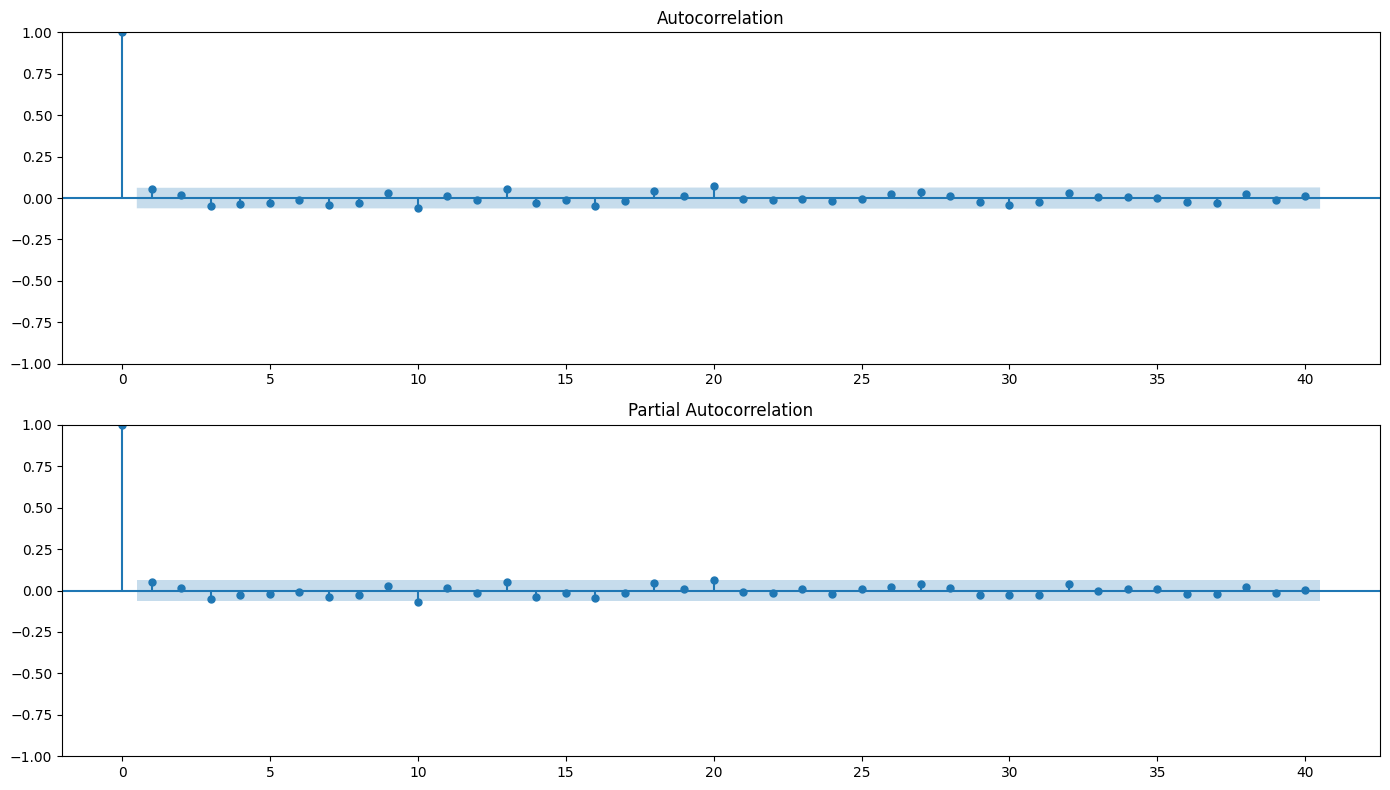

In [5]:
print("\n" + "=" * 60)
print("STEP 4: ACF & PACF ANALYSIS")
print("=" * 60)
 
stationary_series = df['Close_Diff1'].dropna()
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(stationary_series, lags=40, ax=axes[0])
plot_pacf(stationary_series, lags=40, ax=axes[1])
plt.tight_layout()
plt.show()

In [6]:
print("\n" + "=" * 60)
print("STEP 5: TESTING SEASONAL PERIODS")
print("=" * 60)

seasonal_configs = {"m=5 (Weekly)": 5, "m=21 (Monthly)": 21}
for label, m in seasonal_configs.items():
    model_test = pm.auto_arima(train_data, seasonal=True, m=m, stepwise=True, trace=False)
    print(f"Best AIC for {label}: {model_test.aic():.2f}")


STEP 5: TESTING SEASONAL PERIODS
Best AIC for m=5 (Weekly): 2465.86
Best AIC for m=21 (Monthly): 2465.86


In [7]:
print("\n" + "=" * 60)
print("STEP 6: AUTO-ARIMA - NON-SEASONAL")
print("=" * 60)
 
auto_arima_model = pm.auto_arima(train_data, seasonal=False, stepwise=True, trace=True)
best_p, best_d, best_q = auto_arima_model.order
print(f"\nSelected ARIMA order: p={best_p}, d={best_d}, q={best_q}")


STEP 6: AUTO-ARIMA - NON-SEASONAL
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2471.072, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2470.761, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2472.709, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2472.702, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2468.789, Time=0.00 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2467.835, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2469.318, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2469.293, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2472.850, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2472.885, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=2465.859, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=2470.728, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=2470.735, Time=0.00 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=2467.345, Time=0.04 se

In [8]:
print("\n" + "=" * 60)
print("STEP 7: AUTO-SARIMA - SEASONAL (m=5)")
print("=" * 60)
 
auto_sarima_model = pm.auto_arima(train_data, seasonal=True, m=5, stepwise=True, trace=True)
best_P, best_D, best_Q, best_m = auto_sarima_model.seasonal_order
print(f"\nSelected SARIMA order: ({best_p},{best_d},{best_q})({best_P},{best_D},{best_Q})[{best_m}]")


STEP 7: AUTO-SARIMA - SEASONAL (m=5)
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=2474.832, Time=0.28 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=2470.761, Time=0.00 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=2473.527, Time=0.02 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=2473.438, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=2468.789, Time=0.00 sec
 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=2471.586, Time=0.01 sec
 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=2471.508, Time=0.02 sec
 ARIMA(0,1,0)(1,0,1)[5] intercept   : AIC=2473.421, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[5] intercept   : AIC=2472.709, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[5] intercept   : AIC=2472.702, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[5] intercept   : AIC=2467.835, Time=0.04 sec
 ARIMA(1,1,1)(1,0,0)[5] intercept   : AIC=2469.550, Time=0.08 sec
 ARIMA(1,1,1)(0,0,1)[5] intercept   : AIC=2469.537, Time=0.12 sec
 ARIMA(1,1,1)(1,0,1)[5] intercept   : AIC=inf, Time=0.28 sec



STEP 8: ARIMA DIAGNOSTICS


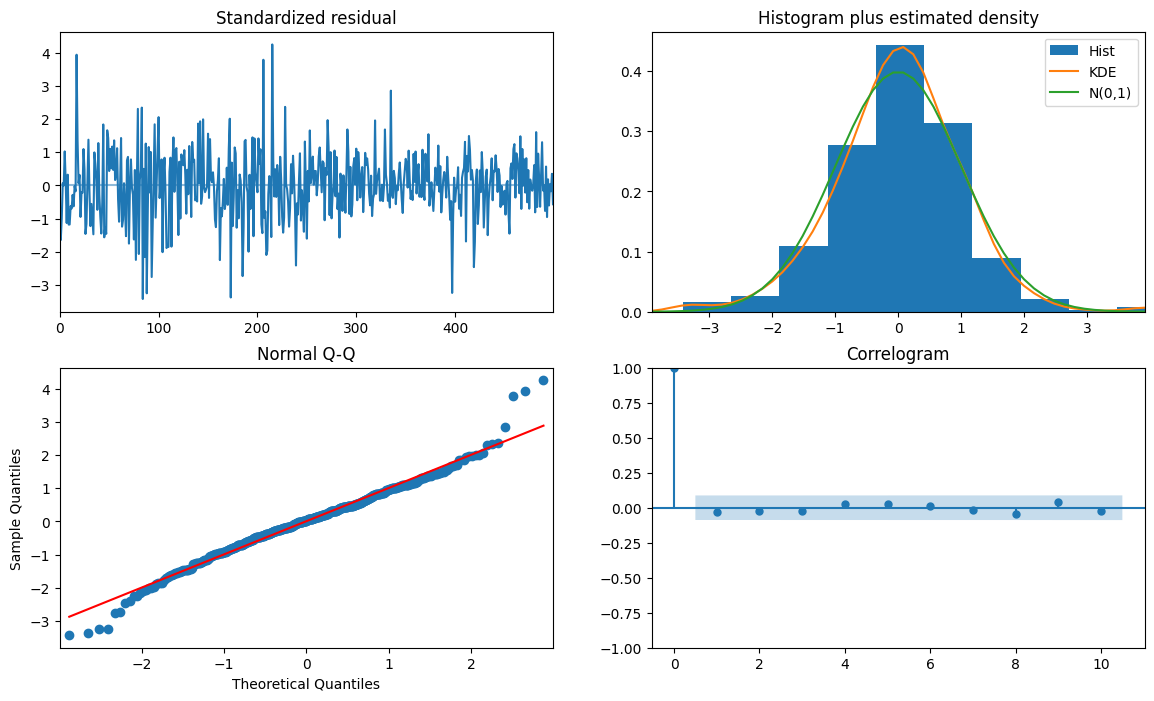

In [9]:
print("\n" + "=" * 60)
print("STEP 8: ARIMA DIAGNOSTICS")
print("=" * 60)
auto_arima_model.plot_diagnostics(figsize=(14, 8))
plt.show()


STEP 9: SARIMA DIAGNOSTICS


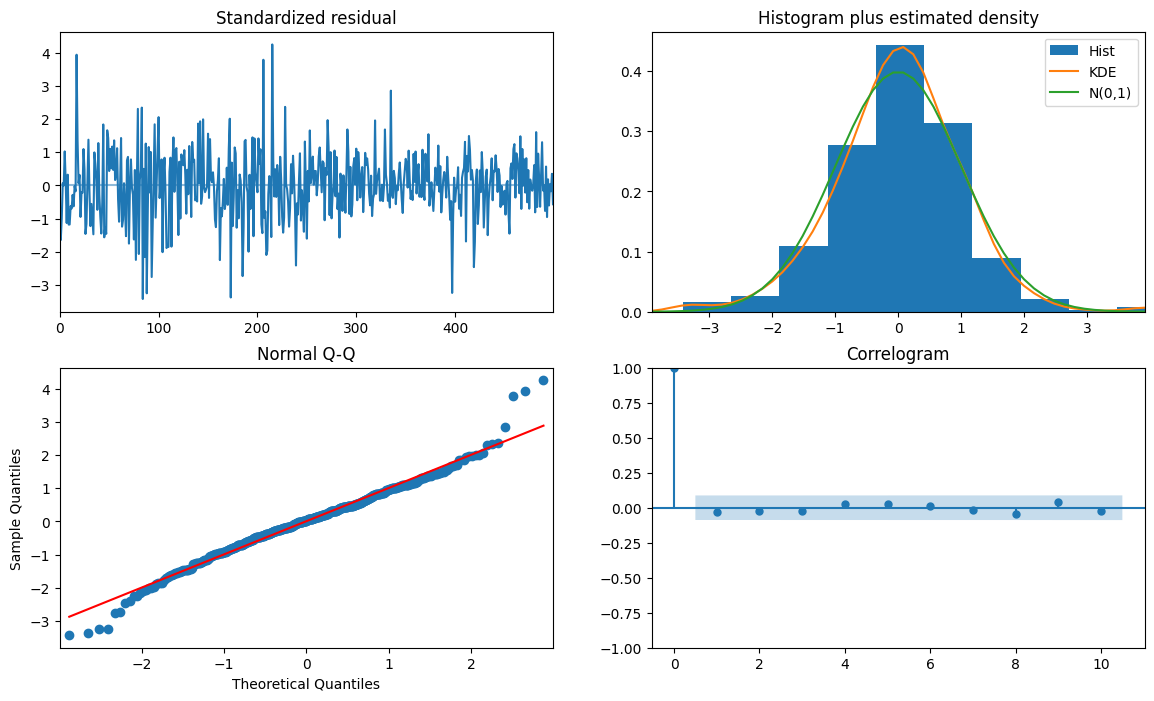

In [10]:
print("\n" + "=" * 60)
print("STEP 9: SARIMA DIAGNOSTICS")
print("=" * 60)
auto_sarima_model.plot_diagnostics(figsize=(14, 8))
plt.show()


STEP 10: ARIMA FORECASTING (Rolling One-Step-Ahead)
Using ARIMA order: (1, 1, 1)
  ARIMA: 50/502 steps completed
  ARIMA: 100/502 steps completed
  ARIMA: 150/502 steps completed
  ARIMA: 200/502 steps completed
  ARIMA: 250/502 steps completed
  ARIMA: 300/502 steps completed
  ARIMA: 350/502 steps completed
  ARIMA: 400/502 steps completed
  ARIMA: 450/502 steps completed
  ARIMA: 500/502 steps completed
ARIMA rolling forecast complete: 502 predictions


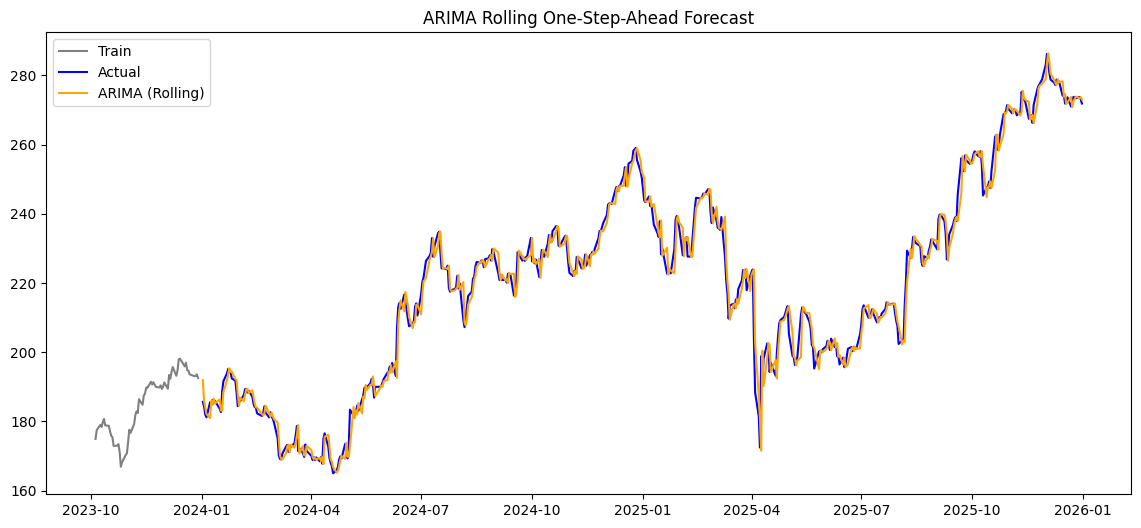

In [11]:
print("\n" + "=" * 60)
print("STEP 10: ARIMA FORECASTING (Rolling One-Step-Ahead)")
print("=" * 60)
 
# Rolling (walk-forward) forecast: predict one step at a time,
# then add the actual observed value to the training set and refit.
# This produces forecasts that follow trends instead of flattening out.
arima_order = auto_arima_model.order
print(f"Using ARIMA order: {arima_order}")

arima_history = list(train_data.values)
arima_predictions = []

for i in range(len(test_data)):
    model = ARIMA(arima_history, order=arima_order)
    model_fit = model.fit()
    yhat = model_fit.forecast(steps=1)[0]
    arima_predictions.append(yhat)
    arima_history.append(test_data.iloc[i])
    if (i + 1) % 50 == 0:
        print(f"  ARIMA: {i + 1}/{len(test_data)} steps completed")

arima_forecast_series = pd.Series(arima_predictions, index=test_data.index)
print(f"ARIMA rolling forecast complete: {len(arima_predictions)} predictions")

plt.figure(figsize=(14, 6))
plt.plot(train_data.iloc[-60:], label='Train', color='gray')
plt.plot(test_data, label='Actual', color='blue')
plt.plot(arima_forecast_series, label='ARIMA (Rolling)', color='orange')
plt.title('ARIMA Rolling One-Step-Ahead Forecast')
plt.legend()
plt.show()


STEP 11: SARIMA FORECASTING (Rolling One-Step-Ahead)
Using SARIMA order: (1, 1, 1) x (0, 0, 0, 5)
  SARIMA: 50/502 steps completed
  SARIMA: 100/502 steps completed
  SARIMA: 150/502 steps completed
  SARIMA: 200/502 steps completed
  SARIMA: 250/502 steps completed
  SARIMA: 300/502 steps completed
  SARIMA: 350/502 steps completed
  SARIMA: 400/502 steps completed
  SARIMA: 450/502 steps completed
  SARIMA: 500/502 steps completed
SARIMA rolling forecast complete: 502 predictions


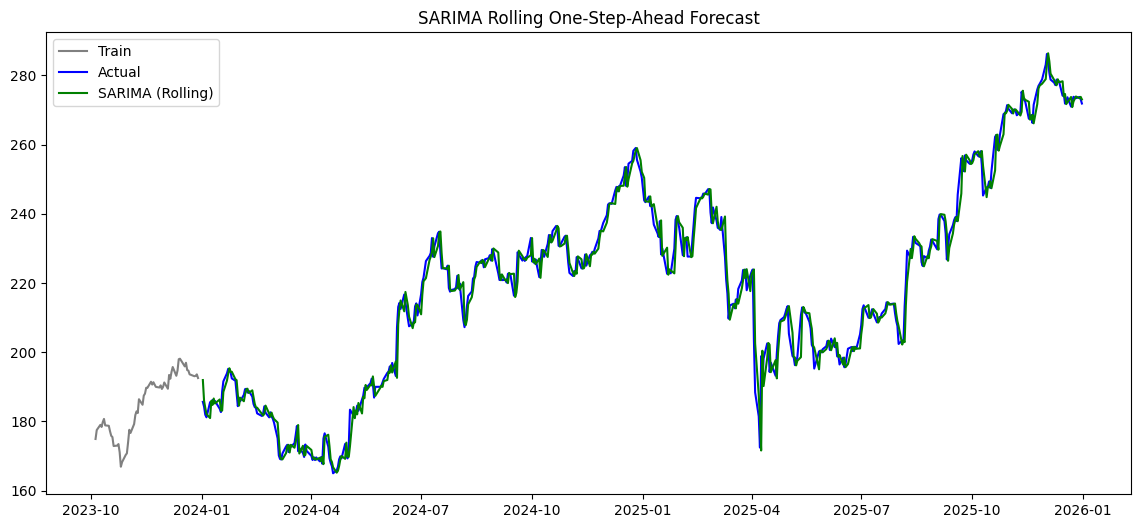

In [12]:
print("\n" + "=" * 60)
print("STEP 11: SARIMA FORECASTING (Rolling One-Step-Ahead)")
print("=" * 60)

# Rolling (walk-forward) forecast for SARIMA
sarima_order = auto_sarima_model.order
sarima_seasonal_order = auto_sarima_model.seasonal_order
print(f"Using SARIMA order: {sarima_order} x {sarima_seasonal_order}")

sarima_history = list(train_data.values)
sarima_predictions = []

for i in range(len(test_data)):
    model = SARIMAX(sarima_history, order=sarima_order, seasonal_order=sarima_seasonal_order)
    model_fit = model.fit(disp=False)
    yhat = model_fit.forecast(steps=1)[0]
    sarima_predictions.append(yhat)
    sarima_history.append(test_data.iloc[i])
    if (i + 1) % 50 == 0:
        print(f"  SARIMA: {i + 1}/{len(test_data)} steps completed")

sarima_forecast_series = pd.Series(sarima_predictions, index=test_data.index)
print(f"SARIMA rolling forecast complete: {len(sarima_predictions)} predictions")

plt.figure(figsize=(14, 6))
plt.plot(train_data.iloc[-60:], label='Train', color='gray')
plt.plot(test_data, label='Actual', color='blue')
plt.plot(sarima_forecast_series, label='SARIMA (Rolling)', color='green')
plt.title('SARIMA Rolling One-Step-Ahead Forecast')
plt.legend()
plt.show()


STEP 12: COMBINED FORECAST COMPARISON


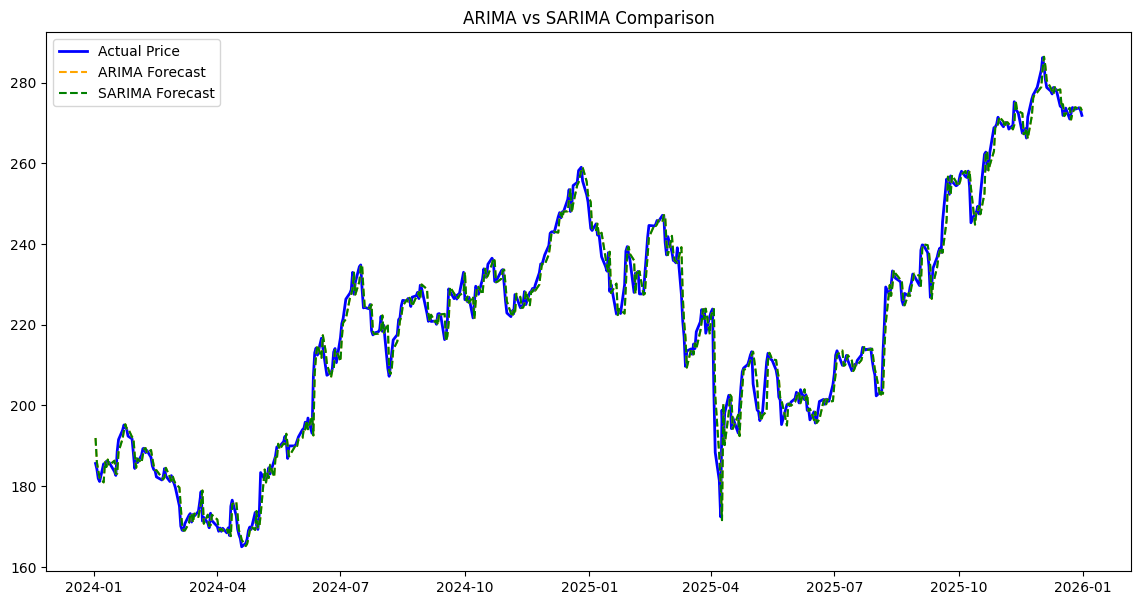

In [13]:
print("\n" + "=" * 60)
print("STEP 12: COMBINED FORECAST COMPARISON")
print("=" * 60)

plt.figure(figsize=(14, 7))
plt.plot(test_data, label='Actual Price', color='blue', linewidth=2)
plt.plot(arima_forecast_series, label='ARIMA Forecast', color='orange', linestyle='--')
plt.plot(sarima_forecast_series, label='SARIMA Forecast', color='green', linestyle='--')
plt.title("ARIMA vs SARIMA Comparison")
plt.legend()
plt.show()

In [14]:
print("\n" + "=" * 60)
print("STEP 13: PERFORMANCE METRICS")
print("=" * 60)

def evaluate(actual, predicted, name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    return {'Model': name, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'MAPE (%)': round(mape, 4)}

results = pd.DataFrame([
    evaluate(test_data, arima_forecast_series, "ARIMA"),
    evaluate(test_data, sarima_forecast_series, "SARIMA")
])

print(results.to_string(index=False))
best = results.loc[results['MAPE (%)'].idxmin(), 'Model']
print(f"\n>>> BEST MODEL: {best} <<<")


STEP 13: PERFORMANCE METRICS
 Model  RMSE    MAE  MAPE (%)
 ARIMA 3.702 2.5094    1.1654
SARIMA 3.702 2.5094    1.1654

>>> BEST MODEL: ARIMA <<<
